## 2. Training CNN with the CIFAR10 dataset
Here I will show my optimized script to train my CNN model based on my hardware capabities.


In [3]:
# Import the dl_utils.py file
import sys, os

# Add the project root to the python path
sys.path.insert(0, os.path.abspath("../DL_utils_EZA")) # Goes up one level from current folder

# Autoreload: picks up edits to dl_utils.py without restarting the kernel
%load_ext autoreload
%autoreload 2

# Import my own utilities
from dl_utils import * #run_epoch, train_simple_network_EZA

print(" dl_utils loaded")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
 dl_utils loaded


In [2]:
# Import dependencies
import torch
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

### Hardware optimization
- Force GPU usage with `torch.backends.cudnn.benchmark`
- Enable Automatic Mixed Precision (AMP): Allows my RTX 2080 Ti to do FP16 math.

In [4]:
# Verification of CUDA present and force deterministic bahaviour for reproducibility with forced GPU usage

torch.backends.cudnn.benchmark = True  # Speeds up CNN training with fixed input sizes

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Device available: {device}')


Device available: cuda


### Data Loading and exploration
Load the CIFAR10 dataset from `torchvision` to build the CNN.

In [28]:
import matplotlib.pyplot as plt
from collections import Counter

In [29]:
# Load raw data (no transforms) for exploration
train_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

In [30]:
# Size and shape
print(f'Train size : {len(train_raw)}')
print(f'Test size : {len(test_raw)}')
print(f'Image array shape: {train_raw.data.shape}')
print(f'Classess: {train_raw.classes}')
print(f'Number of classes: {len(train_raw.classes)}')

Train size : 50000
Test size : 10000
Image array shape: (50000, 32, 32, 3)
Classess: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes: 10


In [31]:
# Class distribution
label_counts = Counter([label for _, label in train_raw])
for cls, count in sorted(label_counts.items()):
    print(f' Class {train_raw.classes[cls]}: {count} samples')

 Class airplane: 5000 samples
 Class automobile: 5000 samples
 Class bird: 5000 samples
 Class cat: 5000 samples
 Class deer: 5000 samples
 Class dog: 5000 samples
 Class frog: 5000 samples
 Class horse: 5000 samples
 Class ship: 5000 samples
 Class truck: 5000 samples


In [32]:
# Pixel statistics: Inform normalization
data = train_raw.data / 255.0       # Normalize to [0,1] first
print(f'\nPer-channel mean: {data.mean(axis=(0,1,2))}')
print(f'Per-channel std: {data.std(axis=(0,1,2))}')


Per-channel mean: [0.49139968 0.48215841 0.44653091]
Per-channel std: [0.24703223 0.24348513 0.26158784]


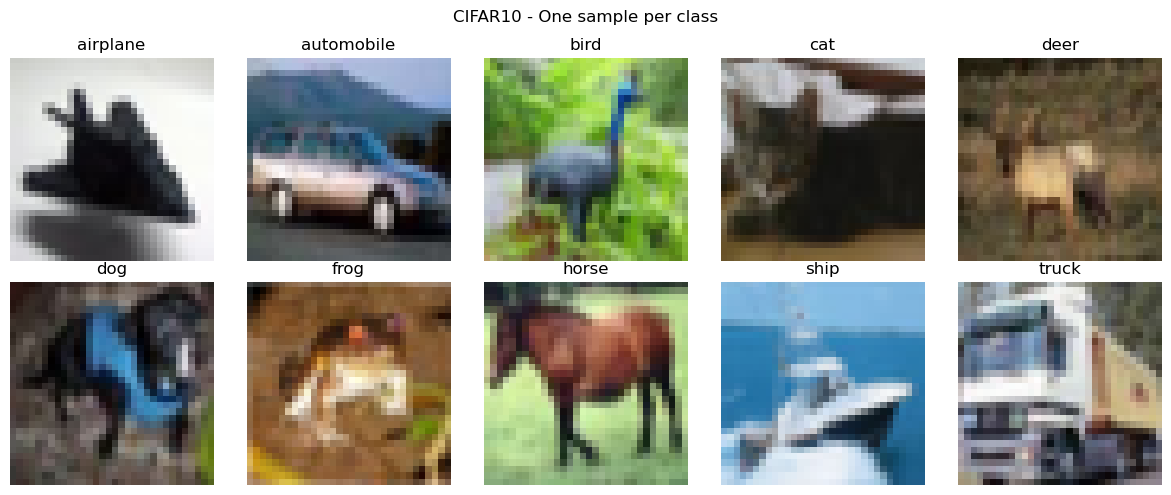

In [10]:
# Visualize samples per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR10 - One sample per class')
seen = {}
for img, label in train_raw:
    if label not in seen:
        seen[label] = img
    if len(seen) == 10:
        break

for ax, (label, img) in zip(axes.flat, sorted(seen.items())):
    ax.imshow(img)
    ax.set_title(train_raw.classes[label])
    ax.axis('off')
plt.tight_layout()
#plt.savefig('./data/others/cifar10_exploration.png', dpi=150)

### Data Loading for training and testing

In [52]:
# Download the CIFAR10 data set
cifar10_data_train = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=transforms.ToTensor())
cifar10_data_test = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=transforms.ToTensor())


In [53]:
# Create the train DataLoaders
batch_s = 128       #Batch size
cifar10_train_loader = DataLoader(
    cifar10_data_train,
    batch_size=batch_s, 
    shuffle=True,
    num_workers=4,
    pin_memory=True,  # Locks memory for faster CPU-->GPU transfer
    persistent_workers=True,  # Keeps workers alive between epochs (faster)
    drop_last=True,   # Delete the last batch that is incomplete as 50,000/128=390.625
)

cifar10_test_loader = DataLoader(
    cifar10_data_test,
    batch_size=2*batch_s,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    )

In [55]:
# Define model variables

# Channels in the input (1 for grayscale)
C = 3
# Number of classes
classes = 10
# Number of filters used
filters = 32
# filters (kernel) size
K = 3
# Number of epochs
epochs = 25

# Define Loss Function
loss_func = nn.CrossEntropyLoss()

In [54]:
# Architecture of the CNN model for CIFAR10

model_cnn_pool = nn.Sequential(
    #Block 1
    nn.Conv2d(C, filters, K, padding=1),
    nn.BatchNorm2d(filters),
    nn.ReLU(),
    nn.Conv2d(filters, filters, K, padding=2),
    nn.BatchNorm2d(filters),
    nn.ReLU(),
    nn.Conv2d(filters, filters, K, padding=1),
    nn.BatchNorm2d(filters),
    nn.ReLU(),
    nn.MaxPool2d(2),      # 32x32 --> 16x16

    #Block 2
    nn.Conv2d(filters, 2*filters, K, padding=1),
    nn.BatchNorm2d(2*filters),
    nn.ReLU(),
    nn.Conv2d(2*filters, 2*filters, K, padding=1),
    nn.BatchNorm2d(2*filters),
    nn.ReLU(),
    nn.Conv2d(2*filters, 2*filters, K, padding=1),
    nn.BatchNorm2d(2*filters),
    nn.ReLU(),
    nn.MaxPool2d(2),       # 16x16 --> 8x8

    nn.Flatten(),
    nn.Linear(2*filters*8*8, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, classes)
)

### Quick Sanity Check
This script before full training confirms that the model and loss function are compatible.

In [56]:
# Sanity check: one forward pass
model_cnn_pool.to(device)
model_cnn_pool.eval()

sample_inputs, sample_labels = next(iter(cifar10_train_loader))
sample_inputs = sample_inputs.to(device)
sample_labels = sample_labels.to(device)

with torch.no_grad():
    sample_output = model_cnn_pool(sample_inputs)

print(f"Input shape  : {sample_inputs.shape}")     # → [128, 3, 32, 32]
print(f"Output shape : {sample_output.shape}")     # → [128, 10]  ← must be 10 classes
print(f"Sample loss  : {loss_func(sample_output, sample_labels).item():.4f}")
# Expected loss near -log(1/10) ≈ 2.303 for a random model

Input shape  : torch.Size([128, 3, 32, 32])
Output shape : torch.Size([128, 10])
Sample loss  : 2.3003


### CNN model training with maxpooling

In [57]:
cifar10_cnn_model_pooled = train_simple_network_EZA(model_cnn_pool,
                                                    loss_func,
                                                    cifar10_train_loader,
                                                    test_loader=cifar10_test_loader,
                                                    score_funcs={'Accuracy': accuracy_score},
                                                    device=device,
                                                    epochs=epochs)

Epoch: 100%|██████████| 25/25 [02:18<00:00,  5.55s/it]


### CNN model training with data augmentation and transformation

In [58]:
# CIFAR10 channel statistics
Cifar10_mean = data.mean(axis=(0,1,2))
Cifar10_std = data.std(axis=(0,1,2))

# Training transform with augmentation and normalization
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(Cifar10_mean, Cifar10_std)
])

# Test transform only deterministic
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(Cifar10_mean, Cifar10_std)
])

# Load datasets
cifar10_transformed_train = torchvision.datasets.CIFAR10("./data", train=True, download=True, transform=train_transform)
cifar10_transformed_test = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=test_transform)

In [59]:
# Create the train DataLoaders for transformation and augmetations
batch_s = 128       #Batch size
cifar10_train_transf_loader = DataLoader(
    cifar10_transformed_train,
    batch_size=batch_s, 
    shuffle=True,
    num_workers=4,
    pin_memory=True,  # Locks memory for faster CPU-->GPU transfer
    persistent_workers=True,  # Keeps workers alive between epochs (faster)
    drop_last=True,   # Delete the last batch that is incomplete as 50,000/128=390.625
)

cifar10_test_transf_loader = DataLoader(
    cifar10_transformed_test,
    batch_size=2*batch_s,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    )

In [60]:
cifar10_cnn_model_transformed = train_simple_network_EZA(model_cnn_pool,
                                                    loss_func,
                                                    cifar10_train_transf_loader,
                                                    test_loader=cifar10_test_transf_loader,
                                                    score_funcs={'Accuracy': accuracy_score},
                                                    device=device,
                                                    epochs=epochs)

Epoch: 100%|██████████| 25/25 [03:56<00:00,  9.48s/it]


<Axes: xlabel='epoch', ylabel='test Accuracy'>

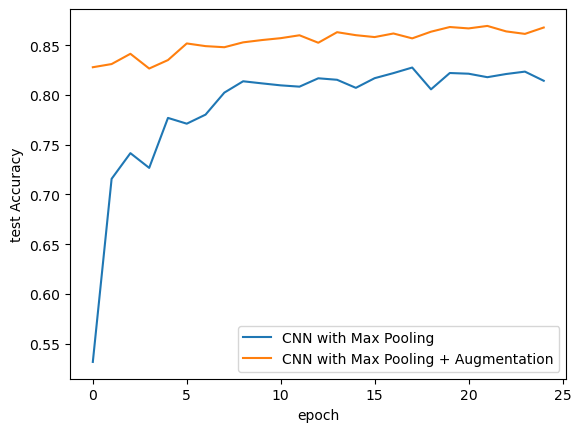

In [61]:
sns.lineplot(x='epoch', y='test Accuracy', data=cifar10_cnn_model_pooled, label='CNN with Max Pooling')
sns.lineplot(x='epoch', y='test Accuracy', data=cifar10_cnn_model_transformed, label='CNN with Max Pooling + Augmentation')

## 3. Testing and Comparing the Trained CNN Models
There are two levels of testing:
1. Single image prediction (visual, intuitive)
2. Batch prediction (statistically meaningful)

Each Model Needs Its Own Transform

Before the code, this is critical. Your two models were trained on different input distributions:
| Model	| What it was trained on | Transform to use at test time |
|:--------------------------|:------------------|:-----------------------------------|
| model_cnn_pool | Raw [0,1] pixels | transforms.ToTensor() only |
| model_cnn_pool_augmented | Normalized pixels | test_transform (ToTensor + Normalize) |

### Step 1 — Setup: Class Names and a Helper Function